In [1]:
import os
import PIL
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

from vae import TinnyVAE, TinnyLinearVAE, loss_vae, train, reconstruct

In [2]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Device is {device}')

Device is cuda


In [3]:
PATH_TO_PHOTOS = '../archive/lfw-deepfunneled'

paths = []
for dirpath, _, filenames in os.walk(PATH_TO_PHOTOS):
    for fname in filenames:
        if fname.endswith('.jpg'):
            paths.append(os.path.join(dirpath, fname))

all_photos = []
for path in paths:
    with open(path, 'rb') as f:
        image = np.array(Image.open(f).convert('RGB'))[80:-80, 80:-80]
        image = np.array(Image.fromarray(image).resize((64, 64), Image.Resampling.LANCZOS))
        all_photos.append(image)

print(f'Photos uploaded: {len(all_photos)}')

Photos uploaded: 13233


In [4]:
train_photos, val_photos = train_test_split(all_photos, train_size=0.9, shuffle=True, random_state=42)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=32)

# VAE

100%|██████████| 50/50 [01:36<00:00,  1.94s/it]


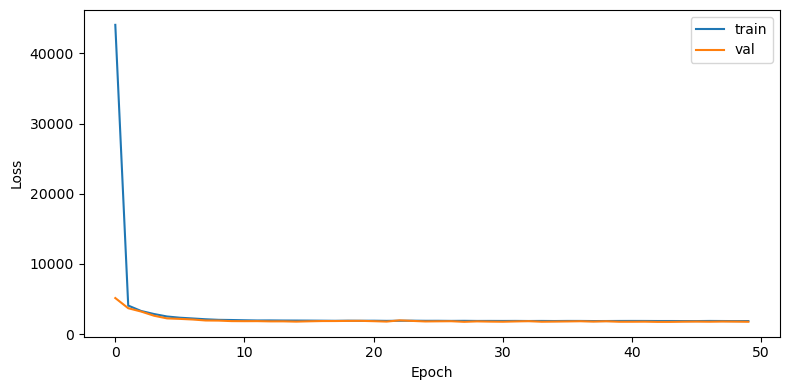

In [5]:
model = TinnyVAE().to(device)

train_losses, val_losses = train(
    model=model,
    n_epochs=50,
    train_loader=train_loader, 
    val_loader=val_loader,
    device=device, 
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
)

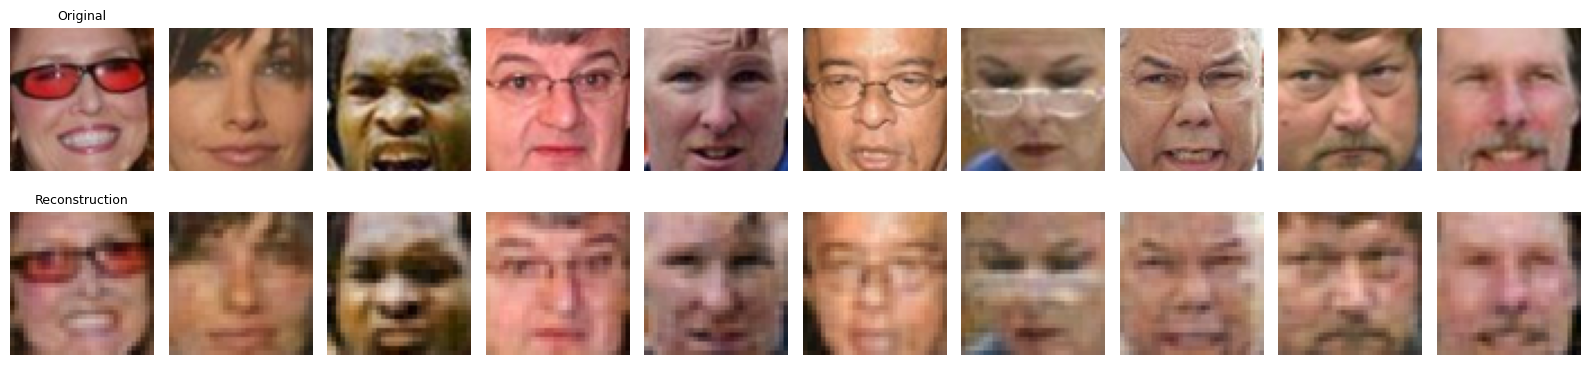

In [6]:
reconstruct(model, val_loader, device)

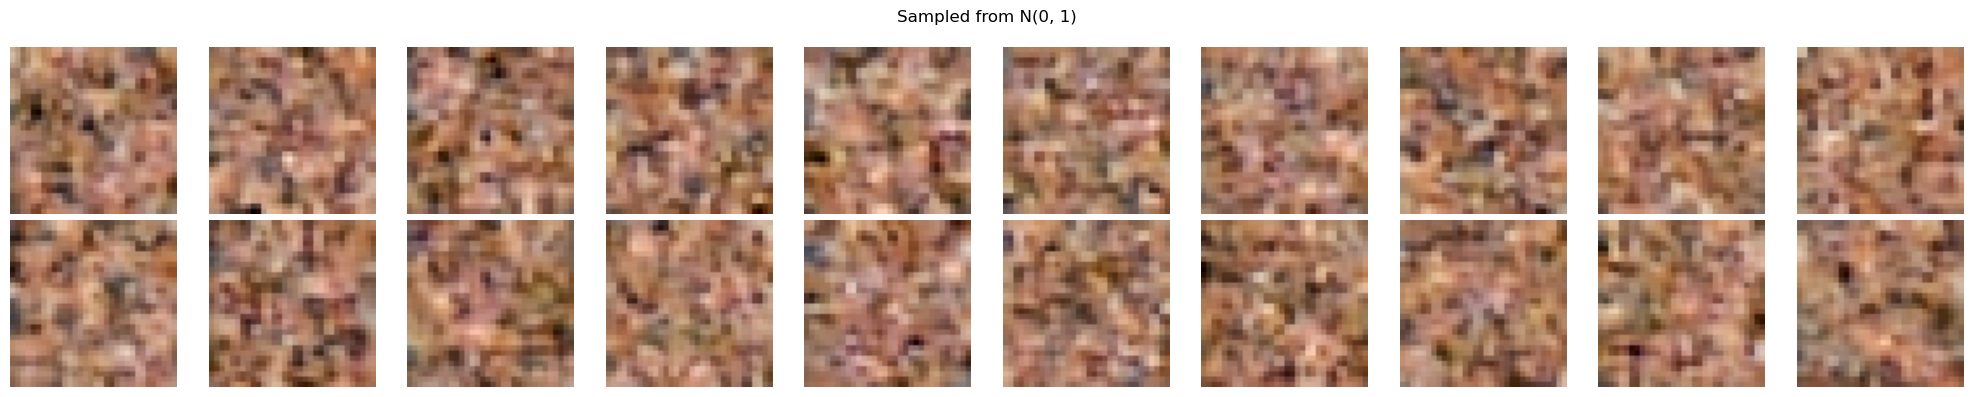

In [7]:
latent_shape = (24, 16, 16)
n_samples = 20
with torch.no_grad():
    z = torch.randn(n_samples, *latent_shape).to(device)
    z = model.decoder['in_conv'](z)
    for i in range(2):
        z = model.decoder[f'block_{i}'](z)
    generated = model.decoder['out_conv'](z)

cols = 10
rows = n_samples // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
for i, ax in enumerate(axes.flat):
    img = generated[i].cpu().permute(1, 2, 0).numpy()
    ax.imshow(img.clip(0, 1))
    ax.axis('off')

plt.suptitle('Sampled from N(0, 1)')
plt.tight_layout()
plt.show()

# Linear-VAE

100%|██████████| 50/50 [01:16<00:00,  1.53s/it]


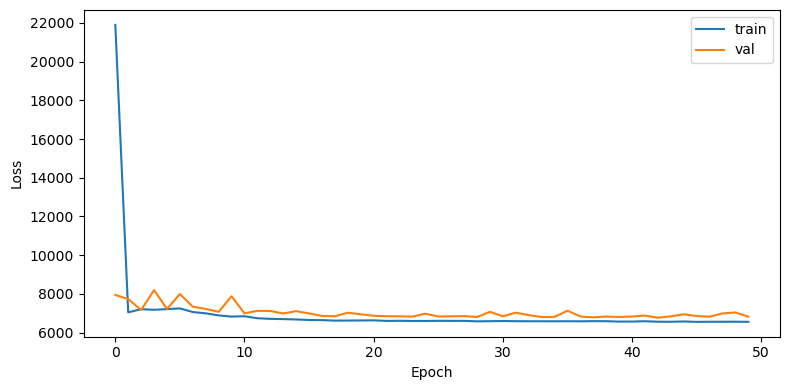

In [8]:
model = TinnyLinearVAE().to(device)

train_losses, val_losses = train(
    model=model,
    n_epochs=50,
    train_loader=train_loader, 
    val_loader=val_loader,
    device=device, 
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
)

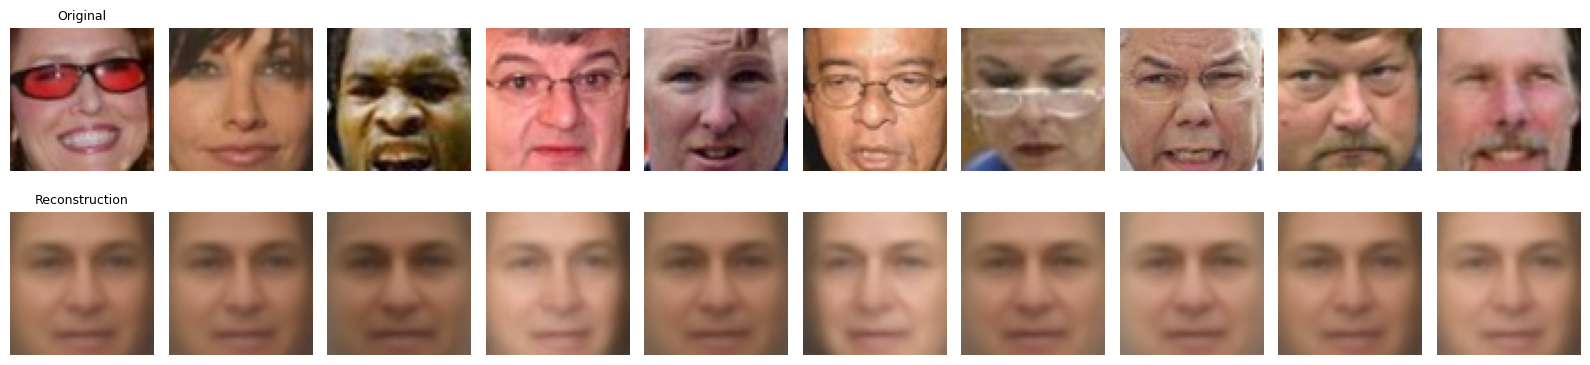

In [9]:
reconstruct(model, val_loader, device)

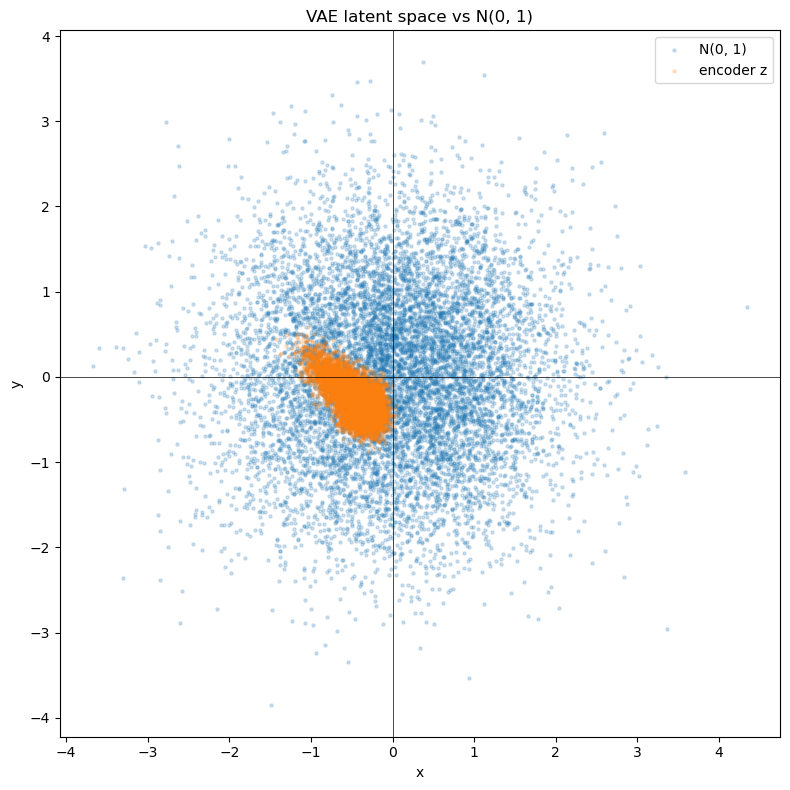

In [10]:
z_arr = []

model.eval()
with torch.no_grad():
    for batch in train_loader:
        batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
        x = batch.reshape((batch.shape[0], -1))
        x = model.encoder(x)

        mu, logvar = torch.chunk(x, 2, dim=-1)
        std = torch.exp(0.5 * logvar)
        epsilon = torch.randn_like(std)
        z = mu + std * epsilon

        z_arr.append(z.cpu().numpy())
z_arr = np.concatenate(z_arr)

z_prior = np.random.randn(10_000, 2)  # samples from N(0, 1)

plt.figure(figsize=(8, 8))
plt.scatter(z_prior[:, 0], z_prior[:, 1], alpha=0.2, s=5, label='N(0, 1)')
plt.scatter(z_arr[:, 0],   z_arr[:, 1],   alpha=0.2, s=5, label='encoder z')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.legend()
plt.title('VAE latent space vs N(0, 1)')
plt.xlabel('x'); plt.ylabel('y')
plt.tight_layout()
plt.show()

We can see that latents sampled from $\mathcal{N}(0, I)$, are spread across the entire plane, whereas latents produced by the VAE occupy a bounded region. In the R2\mathbb{R}^2
R2 case there's still a reasonably high chance of landing inside the cluster the VAE builds, but as the dimensionality of the latent space grows, the VAE's cluster can occupy an exponentially smaller fraction of the hypervolume relative to $\mathcal{N}(0, I)$ — so the probability of hitting a valid latent by random sampling tends to zero.